# 📱 Liquidity Stress Prediction Challenge - Starter Notebook

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a customer is likely to experience liquidity stress, using historical mobile money behaviour.

This notebook walks through a simple end-to-end pipeline:

- Loading and exploring the data
- Preprocessing
- Training a baseline model
- Evaluating performance
- Generating predictions for submission

The baseline model used here is **Logistic Regression**, which is a good starting point for tabular classification problems.


In [ ]:
# 📚 Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


In [ ]:
# 📥 Load the Data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

TARGETLOGLOSS = 'TargetLogLoss'
TARGETRAUC = 'TargetRAUC'

# Create a sample submission template directly from the test IDs
sample_submission = pd.DataFrame({
    "ID": test["ID"],
    TARGETLOGLOSS: 0.5,
    TARGETRAUC: 0.5
})

# Peek at the data
train.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

## 🔍 Exploratory Data Analysis (EDA)

Let’s explore the training data to understand the features and target.


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 184 entries, arpu to ID
dtypes: float64(134), int64(44), object(6)
memory usage: 56.2+ MB


In [ ]:
# Check missing values
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)


,0


### 🏷️ Encoding Categorical Variables

We use **one-hot encoding** to convert categorical columns into numeric format so they can be used by the model.


In [ ]:
# Identify categorical columns
TARGET = "liquidity_stress_next_30d"
ID_COL = "ID"

cat_cols = [c for c in train.columns if train[c].dtype == "object" and c not in [ID_COL]]
cat_cols


['gender', 'region', 'smartphone', 'segment', 'earning_pattern']

In [ ]:
# Apply one-hot encoding to both train and test
train_encoded = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test, columns=cat_cols, drop_first=True)

# Align columns so train and test have the same feature columns
train_encoded, test_encoded = train_encoded.align(test_encoded, join="left", axis=1, fill_value=0)

train_encoded.head()


,arpu,age,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highest_amount,m5_withdraw_agents,m6_withdraw_volume,m

In [ ]:
# Fill missing numeric values with the median of each column
feature_cols = [c for c in train_encoded.columns if c not in [TARGET, ID_COL]]

for col in feature_cols:
    train_encoded[col] = train_encoded[col].fillna(train_encoded[col].median())
    if col in test_encoded.columns:
        test_encoded[col] = test_encoded[col].fillna(train_encoded[col].median())

print("Remaining missing values in train:", train_encoded[feature_cols].isnull().sum().sum())
print("Remaining missing values in test :", test_encoded[feature_cols].isnull().sum().sum())


Remaining missing values in train: 0
Remaining missing values in test : 0


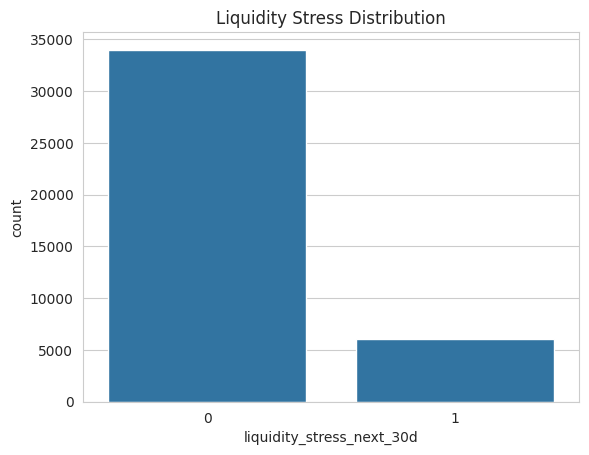

In [ ]:
# Distribution of target variable
sns.countplot(x=TARGET, data=train)
plt.title("Liquidity Stress Distribution")
plt.show()


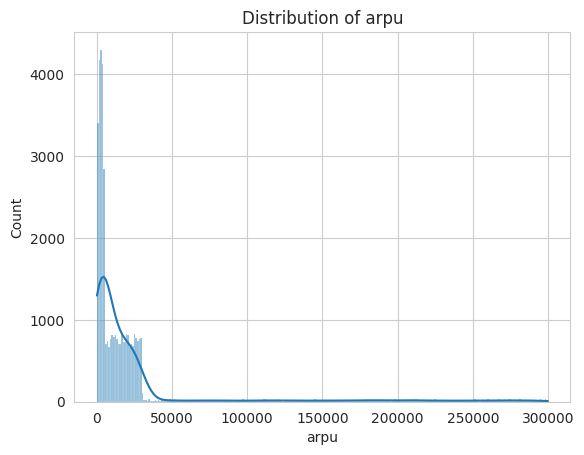

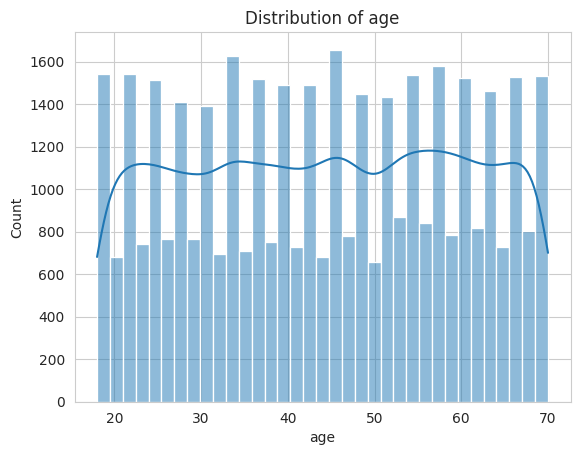

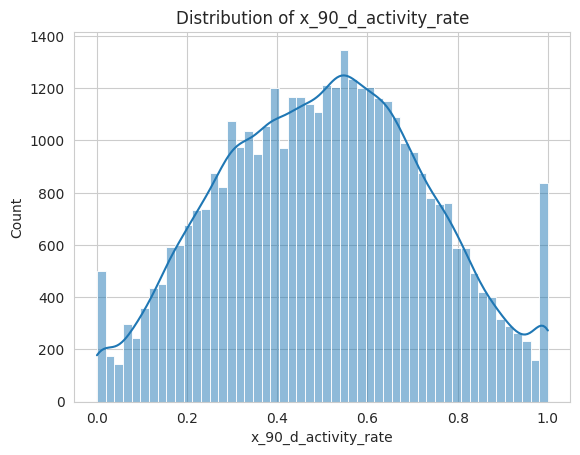

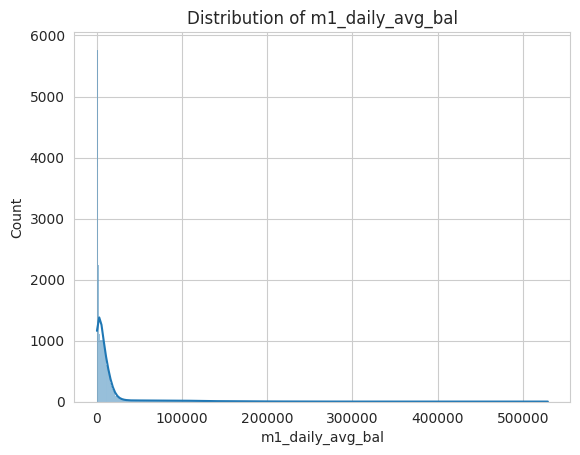

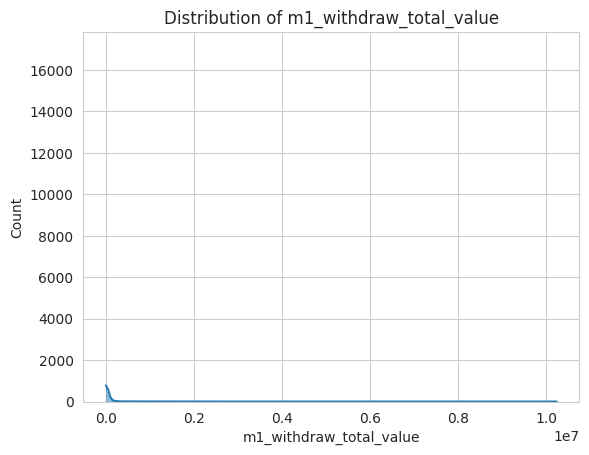

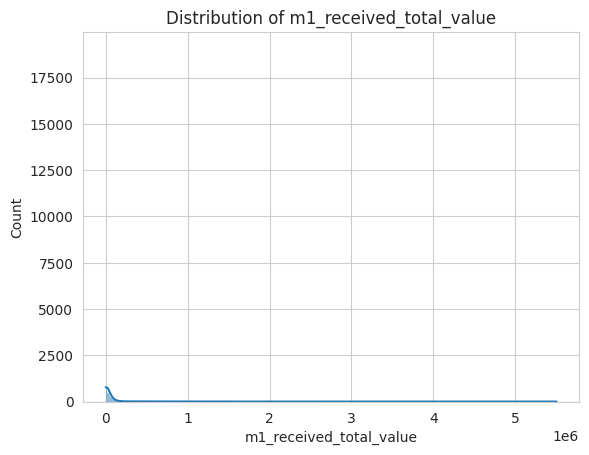

In [ ]:
# Plot distributions of a few useful numeric features
num_features = [
    "arpu",
    "age",
    "x_90_d_activity_rate",
    "m1_daily_avg_bal",
    "m1_withdraw_total_value",
    "m1_received_total_value"
]

for col in num_features:
    if col in train.columns:
        sns.histplot(train[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


## 🧹 Preprocessing

We’ll split the training data into features and target, then create a validation set.


In [ ]:
# Features and target
X = train_encoded.drop(columns=[TARGET, ID_COL])
y = train_encoded[TARGET]

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_val.shape


((32000, 189), (8000, 189))

In [ ]:
X_cols = train_encoded.drop(columns=[TARGET, ID_COL]).columns
len(X_cols)


189

## 🤖 Model Training

We’ll use a Logistic Regression classifier as our baseline model.


In [ ]:
# Train a Logistic Regression model
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=100,
                                class_weight="balanced",
                                solver="liblinear")
    )
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])

In [ ]:
# Predict on validation set
val_pred_prob = pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation ROC-AUC: 0.7531676470588237

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      6800
           1       0.28      0.70      0.40      1200

    accuracy                           0.69      8000
   macro avg       0.61      0.69      0.60      8000
weighted avg       0.83      0.69      0.73      8000



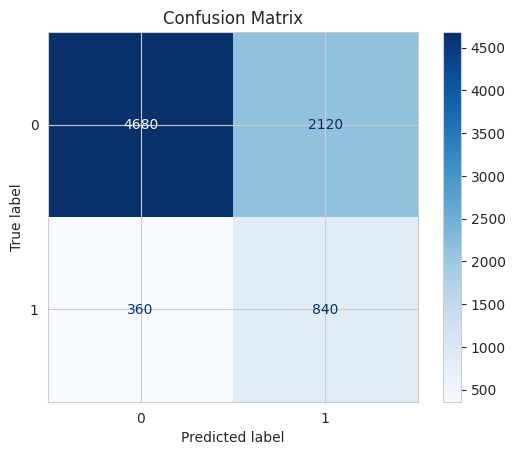

In [ ]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## 📊 Feature Importance

Let’s see which features are most important to the model.


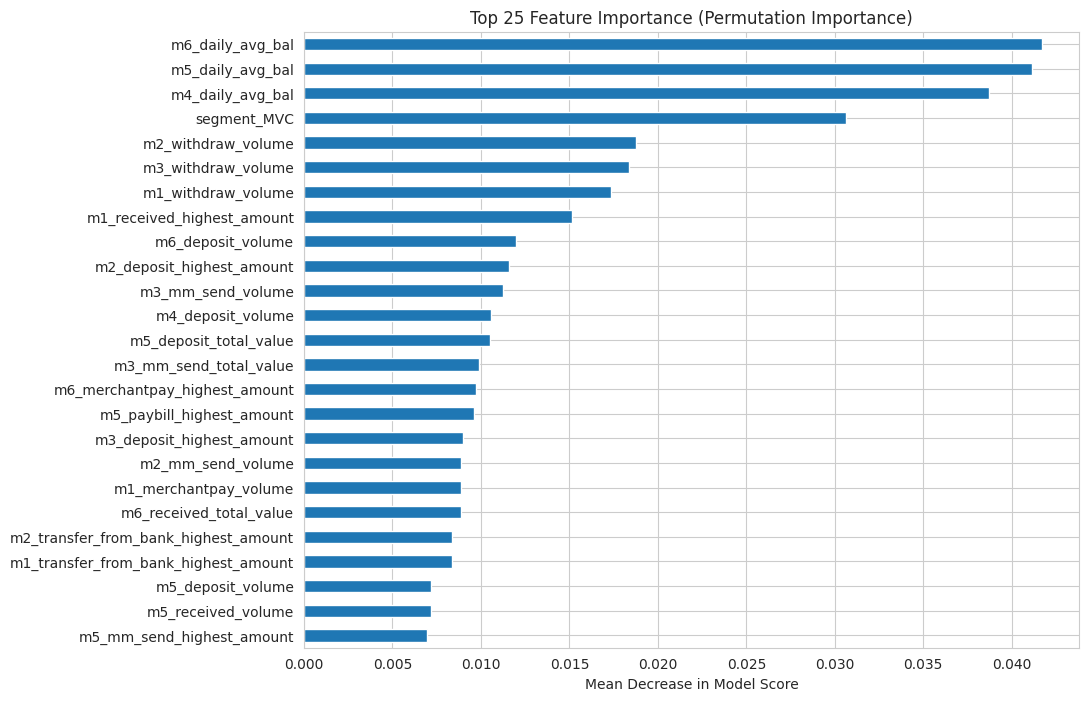

In [ ]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    pipeline,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X_cols)

(
    importances
    .sort_values(ascending=False)
    .head(25)
    .sort_values()
    .plot(kind="barh", figsize=(10,8))
)

plt.title("Top 25 Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in Model Score")
plt.show()

## 🚀 Predictions on Test Set

Let’s predict on the test set and generate a submission file.


In [ ]:
# Retrain the model on the full training set
pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])

In [ ]:
X.shape, y.shape

((40000, 189), (40000,))

In [ ]:
# Predict probabilities on test data,
# Drop liquidity_stress_next_30d from test_features. It is only there as a placeholder for encoding
test_features = test_encoded.drop(columns=[ID_COL, TARGET])
test_features.head()

,arpu,age,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highest_amount,m5_withdraw_agents,m6_withdraw_volume,m

In [ ]:
set(X.columns) - set(test_features.columns)

set()

In [ ]:
set(test_features.columns) - set(X.columns)

set()

In [ ]:
# Predict probabilities on test data
test_predictions =  pipeline.predict_proba(test_features)[:, 1]

In [ ]:
# Prepare submission
submission = sample_submission.copy()
submission[TARGETLOGLOSS] = test_predictions
submission[TARGETRAUC] = test_predictions

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,TargetLogLoss,TargetRAUC
0,ID_ED91AC7A28,0.200192,0.200192
1,ID_29975A9C7E,0.264043,0.264043
2,ID_F59CE25650,0.186590,0.186590
3,ID_E875F68D1A,0.051112,0.051112
4,ID_2902B1C0D0,0.129903,0.129903


## ✅ What’s Next?

This is just a baseline model. You are welcome to improve upon it or design your own pipeline from scratch!

Good luck, and happy modelling! 🚀


In [ ]:
reference = pd.read_csv('Reference.csv')
y_true = reference[TARGETRAUC].values

In [ ]:
from sklearn.metrics import log_loss

score = log_loss(y_true, test_predictions)

print("Log Loss:", score)

Log Loss: 0.5950609673878794


In [ ]:
# Compute ROC-AUC
roc_auc = roc_auc_score(y_true, test_predictions)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7520144749455338
